In [1]:
# ==============================================================================
# STEP 0: SETUP AND SECTOR FILTER
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import yfinance as yf

# Set a basic visual style
sns.set_theme(style="whitegrid")

# Assign sector based on the last digit of Student ID
sector_map = {
    1: 'Healthcare', 2: 'Financial Services', 3: 'Consumer Cyclical',
    4: 'Consumer Defensive', 5: 'Communication Services', 6: 'Energy',
    7: 'Industrials', 8: 'Basic Materials', 9: 'Real Estate', 0: 'Utilities'
}

my_student_id_last_digit = 3  
my_sector = sector_map[my_student_id_last_digit]
print(f"My assigned sector is: {my_sector}")

# Load the dataset
df_raw = pd.read_csv('symbol_info_3-25.csv') 

# Filter the dataframe (Active stocks, no ETFs, no Funds, only my sector)
df_filtered = df_raw[
    (df_raw['is_actively_trading'] == 1) & 
    (df_raw['is_etf'] == 0) & 
    (df_raw['is_fund'] == 0) & 
    (df_raw['sector'] == my_sector)
].copy()

My assigned sector is: Consumer Cyclical


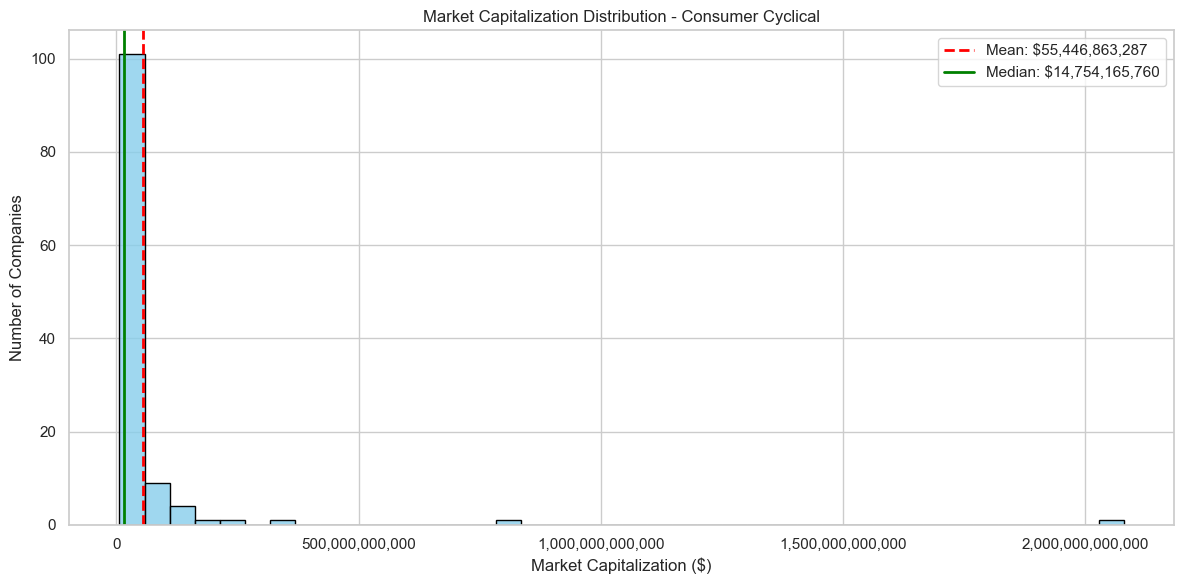

In [2]:
# ==============================================================================
# STEP 1: MARKET CAPITALIZATION DISTRIBUTION
# ==============================================================================

# Set up figure size and proportions
fig, ax = plt.subplots(figsize=(12, 6))

# Drop missing values to avoid calculation errors
mcap_series = df_filtered['market_cap'].dropna()

# Plot histogram
sns.histplot(mcap_series, bins=40, color="skyblue",edgecolor="black", linewidth=1,  alpha=0.8, ax=ax)

# Calculate mean and median
mean_val = mcap_series.mean()
median_val = mcap_series.median()

# Add vertical lines for mean and median
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: ${mean_val:,.0f}")
ax.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f"Median: ${median_val:,.0f}")

# Formatting
ax.set_title(f"Market Capitalization Distribution - {my_sector}")
ax.set_xlabel("Market Capitalization ($)")
ax.set_ylabel("Number of Companies")

# Format X-axis with commas for readability
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Use a standard legend instead of floating text boxes
plt.legend()
plt.tight_layout()
plt.show()

--- OUTLIER CLEANING REPORT ---
Upper Bound Threshold: $65,452,651,776
Outliers removed: 17
Companies remaining in 'df_clean': 102


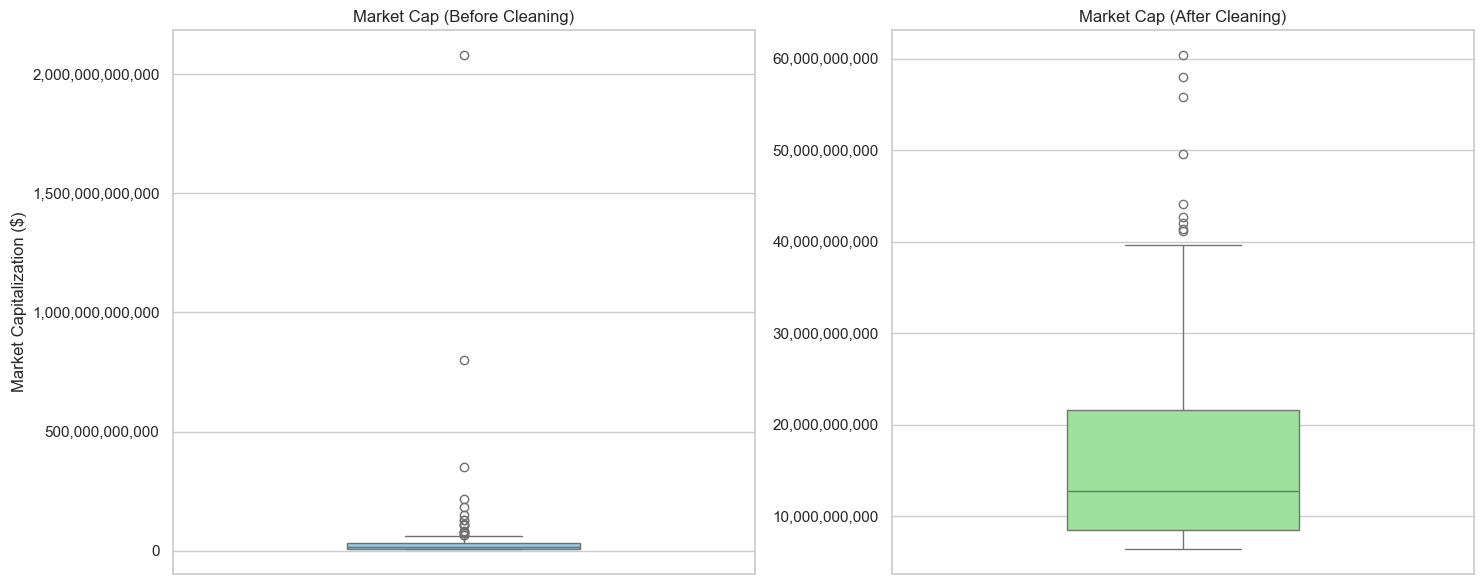

In [3]:
# ==============================================================================
# STEP 2: OUTLIER DETECTION
# ==============================================================================

# Set up a figure with two subplots side-by-side (Before and After)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot before outlier removal
sns.boxplot(y=df_filtered['market_cap'], color='skyblue', ax=ax1, width=0.4)
ax1.set_title("Market Cap (Before Cleaning)")
ax1.set_ylabel("Market Capitalization ($)")
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Outlier Detection using the IQR Method
Q1 = df_filtered['market_cap'].quantile(0.25)
Q3 = df_filtered['market_cap'].quantile(0.75)
IQR = Q3 - Q1

# Define the bounds
upper_bound = Q3 + 1.5 * IQR
lower_bound = max(0, Q1 - 1.5 * IQR) # Market cap cannot be negative

# Filter the dataset to remove outliers
df_clean = df_filtered[(df_filtered['market_cap'] >= lower_bound) & 
                       (df_filtered['market_cap'] <= upper_bound)].copy()

# Calculate how many outliers were removed
outliers_removed = len(df_filtered) - len(df_clean)
print(f"--- OUTLIER CLEANING REPORT ---")
print(f"Upper Bound Threshold: ${upper_bound:,.0f}")
print(f"Outliers removed: {outliers_removed}")
print(f"Companies remaining in 'df_clean': {len(df_clean)}")

# Plot after outlier removal
sns.boxplot(y=df_clean['market_cap'], color='lightgreen', ax=ax2, width=0.4)
ax2.set_title("Market Cap (After Cleaning)")
ax2.set_ylabel("") # Hide y-label for the second plot
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

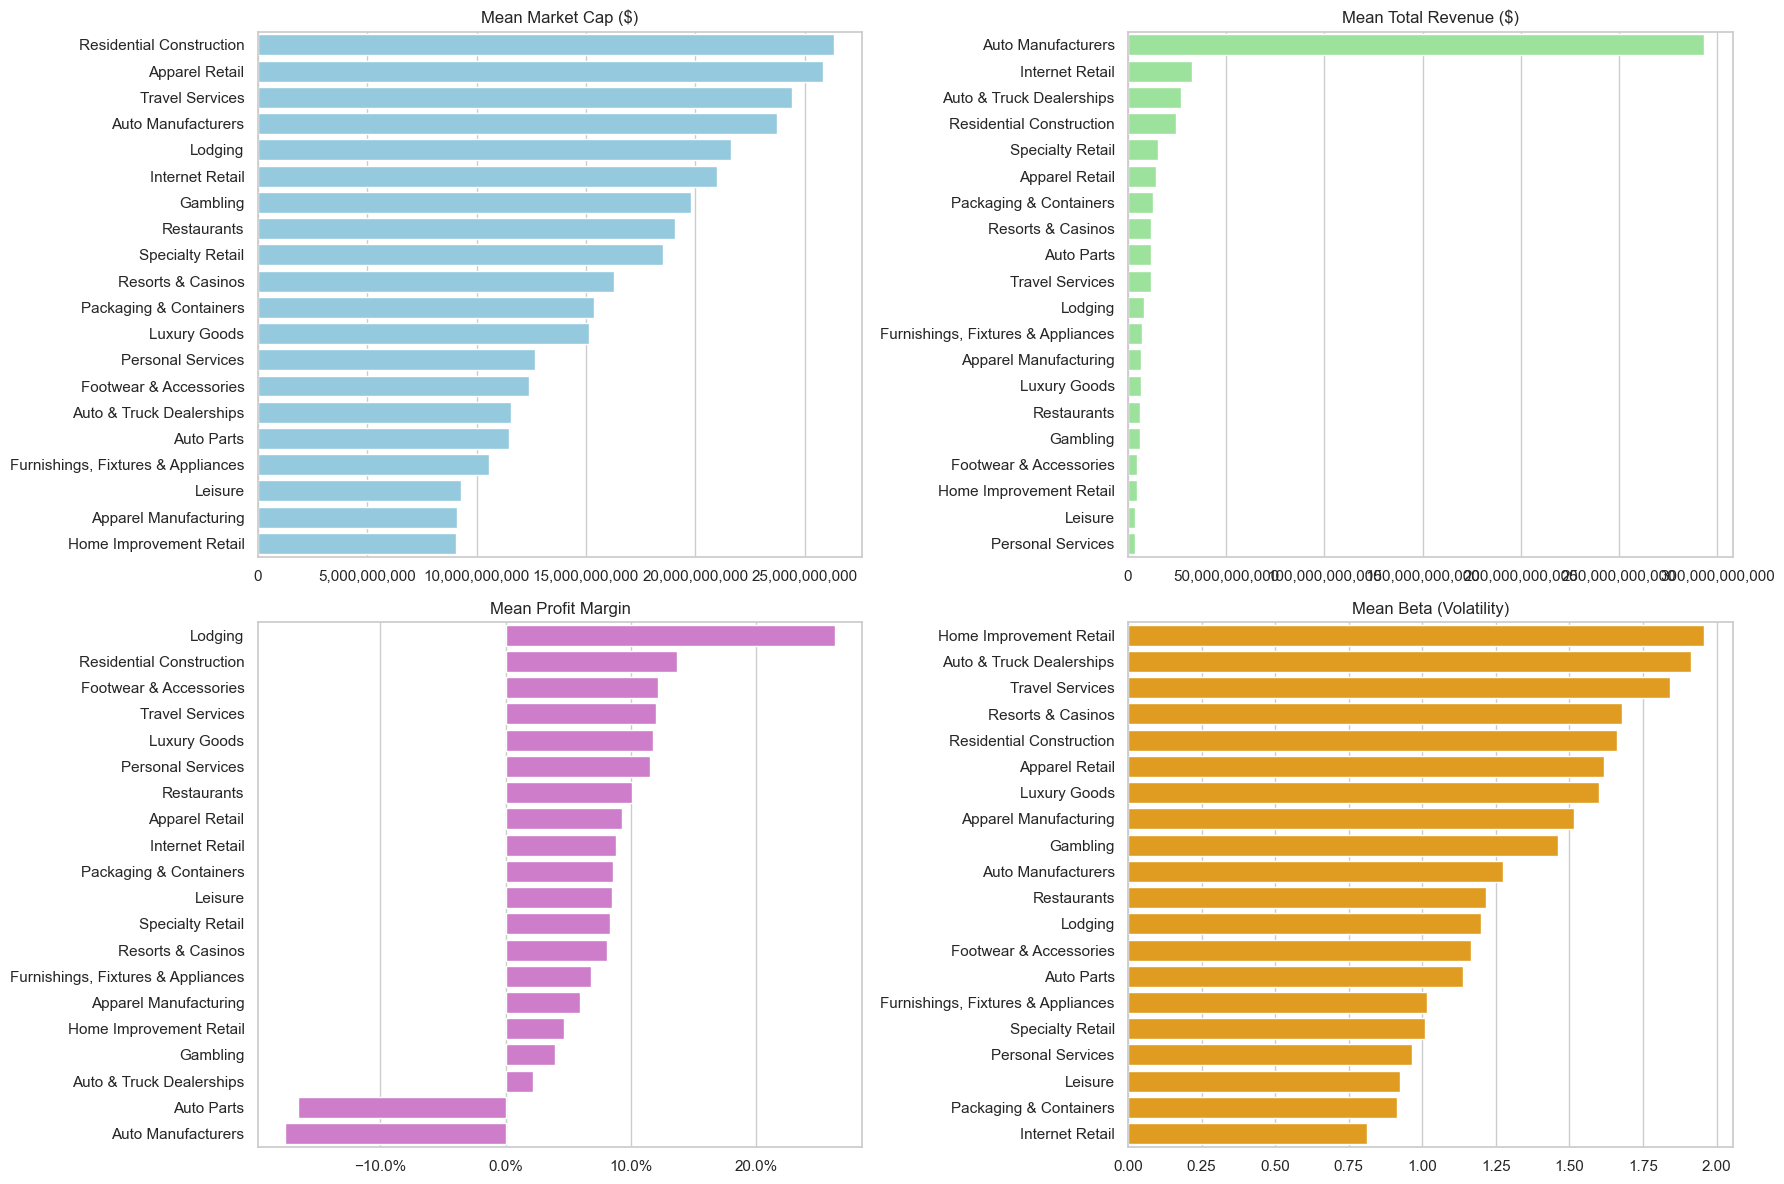

In [4]:
# ==============================================================================
# STEP 3: INDUSTRY COMPARISON - FOUR METRICS
# ==============================================================================

# Comment (Justification of choice): 
# I grouped the cleaned dataset by 'industry' to calculate the mean 
# for each metric. I chose to sort the bars in descending order for each subplot easily identify 
# the leading and lagging industries.

# Define metrics and calculate the mean
metrics = ['market_cap', 'total_revenue', 'profit_margins', 'beta']
industry_means = df_clean.groupby('industry')[metrics].mean().reset_index()

# Set up a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x2 grid into a simple 1D list to easily loop through them

# Colors and titles for each specific metric
colors = ['skyblue', 'lightgreen', 'orchid', 'orange']
titles = ['Mean Market Cap ($)', 'Mean Total Revenue ($)', 'Mean Profit Margin', 'Mean Beta (Volatility)']

# Create a horizontal bar chart for each metric
for i, metric in enumerate(metrics):
    
    # Sort the data for the current metric
    sorted_data = industry_means.sort_values(by=metric, ascending=False)
    
    # Plot the horizontal bar chart
    sns.barplot(x=metric, y='industry', data=sorted_data, ax=axes[i], color=colors[i])
    
    # Clean up titles and axis labels
    axes[i].set_title(titles[i])
    axes[i].set_ylabel("") # Hide the 'industry' text on the y-axis to avoid clutter
    axes[i].set_xlabel("")
    
    # Format the X-axis numbers
    if metric in ['market_cap', 'total_revenue']:
        axes[i].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    elif metric == 'profit_margins':
        axes[i].xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
        
plt.tight_layout()
plt.show()

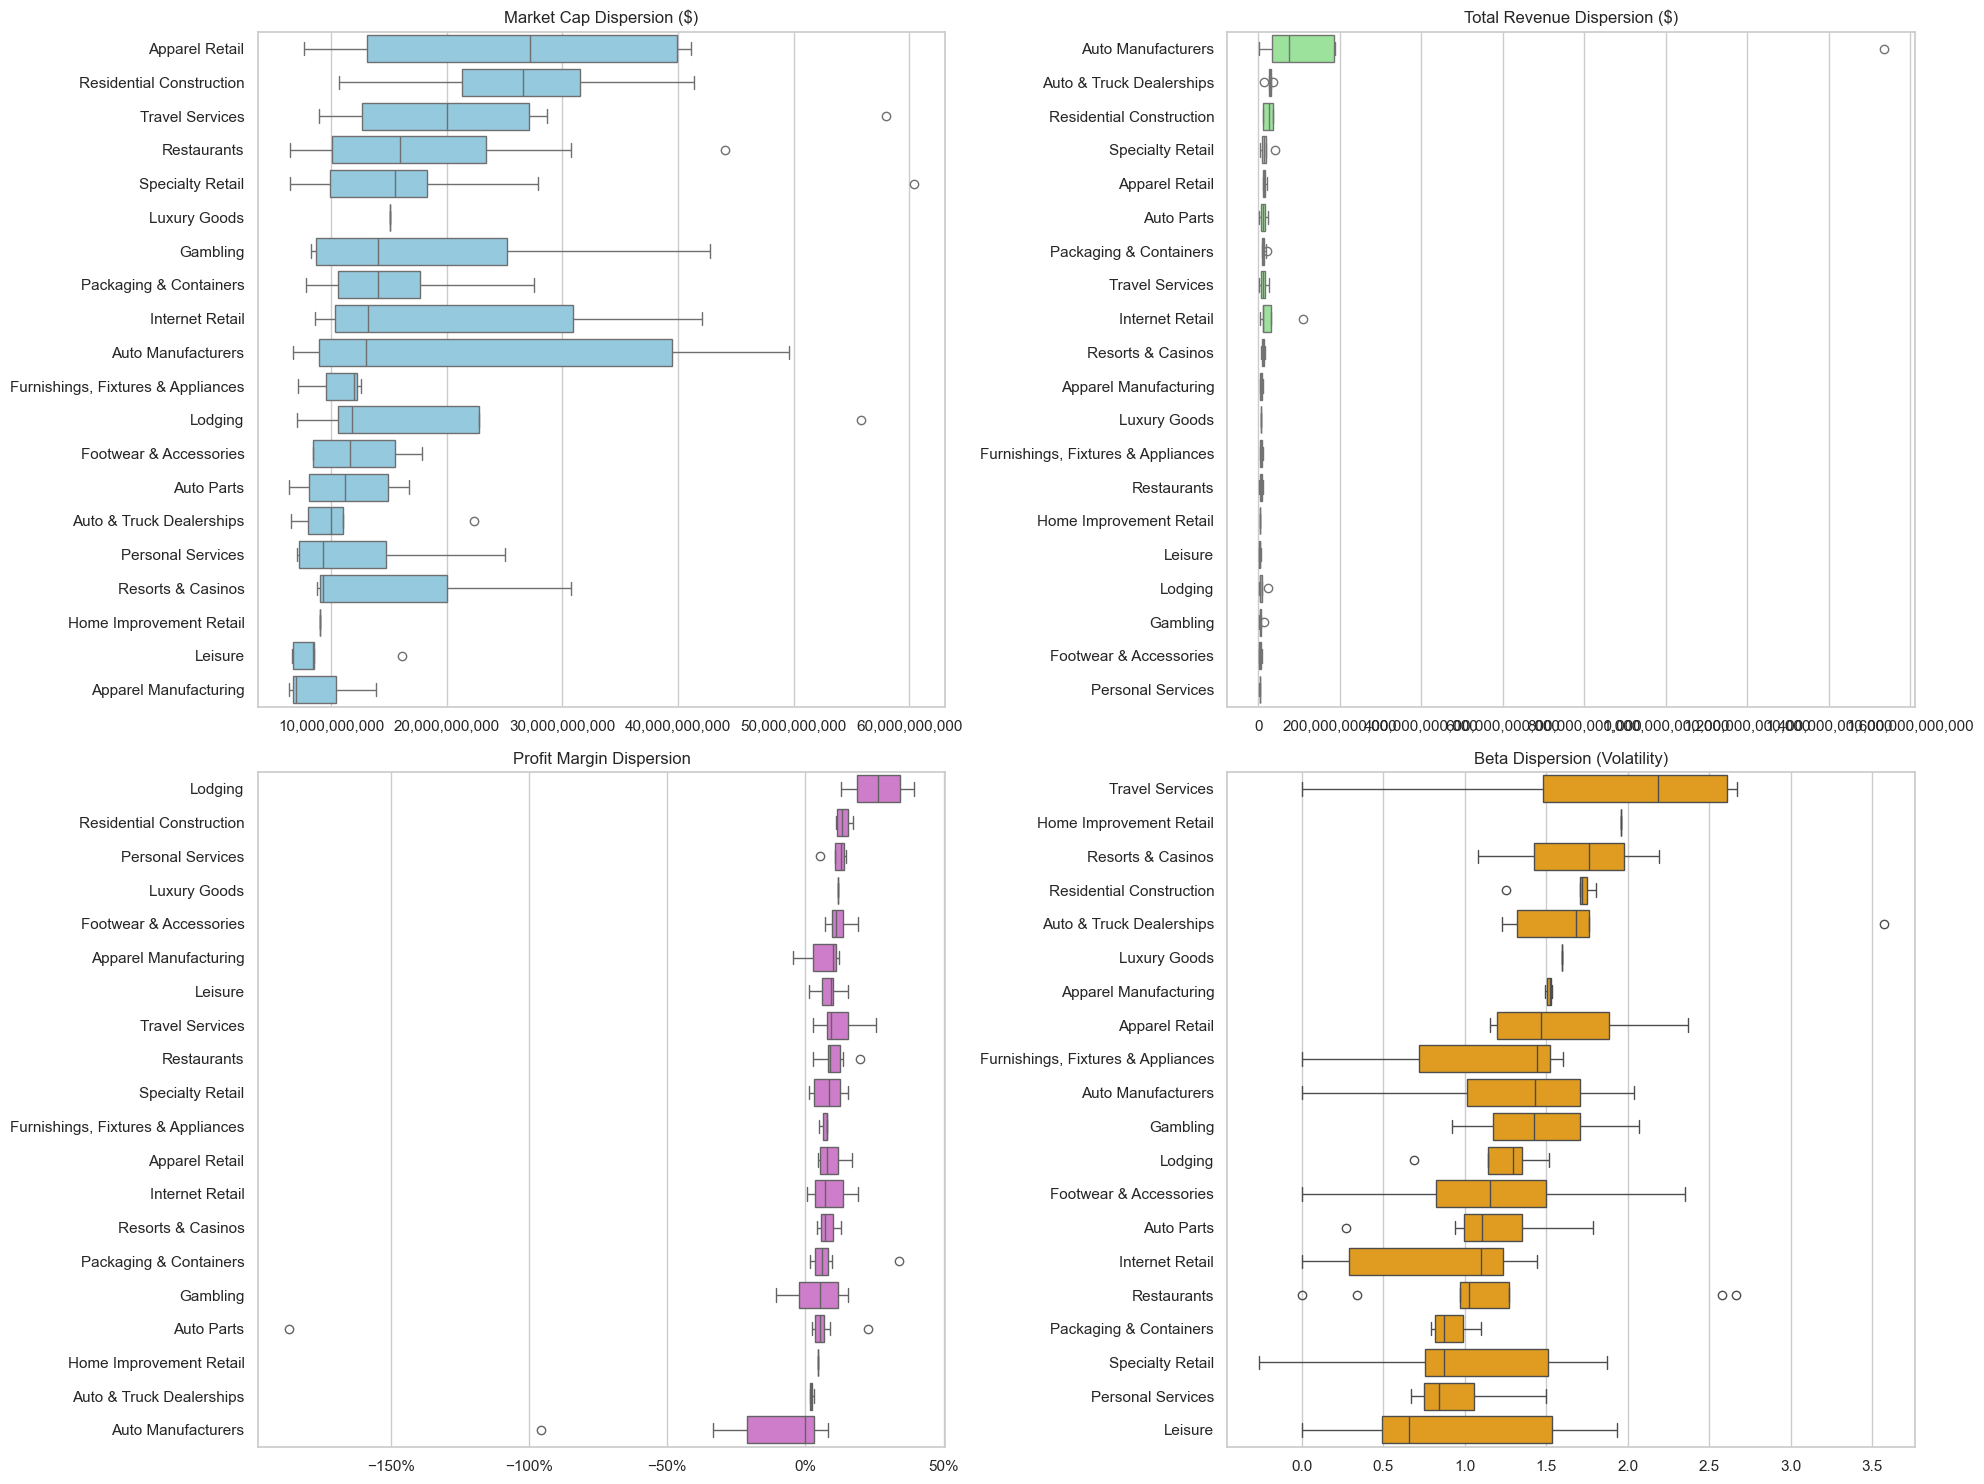

In [5]:
# ==============================================================================
# STEP 4: INDUSTRY DISPERSION
# ==============================================================================

# Justification: 
# Boxplots are used here to show the full distribution and variance within each industry, 
# rather than just the average. Industries are sorted by median for easier comparison.

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

# Define metrics, titles, and colors
metrics = ['market_cap', 'total_revenue', 'profit_margins', 'beta']
titles = ['Market Cap Dispersion ($)', 'Total Revenue Dispersion ($)', 'Profit Margin Dispersion', 'Beta Dispersion (Volatility)']
colors = ['skyblue', 'lightgreen', 'orchid', 'orange']

# Loop through each metric to create the 4 boxplots
for i, metric in enumerate(metrics):
    
    # Sort industries by median
    sorted_industries = df_clean.groupby('industry')[metric].median().sort_values(ascending=False).index
    
    # Plot the horizontal boxplot
    sns.boxplot(x=metric, y='industry', data=df_clean, ax=axes[i], order=sorted_industries, color=colors[i])
    
    # Clean up titles and axis labels
    axes[i].set_title(titles[i])
    axes[i].set_ylabel("") 
    axes[i].set_xlabel("")
    
    # Format the X-axis numbers
    if metric in ['market_cap', 'total_revenue']:
        axes[i].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    elif metric == 'profit_margins':
        axes[i].xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
        
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# STEP 5: FOCUS INDUSTRY SELECTION
# ==============================================================================

# Justification for selection:
# Based on the previous charts, I selected 4 industries with strong contrasts:
# - Auto Manufacturers: Dominates in Total Revenue.
# - Lodging: Exceptional profitability (highest profit margins, >26%).
# - Residential Construction: Very solid foundation (#1 in Market Cap, high margins).
# - Travel Services: Selected for its high volatility (high Beta) and large Market Cap.
# The other industries were dropped because their overall metrics (size, revenue, margins) 
# were significantly lower and didn't stand out in the Step 3 & 4 visualizations.

# Define the 4 chosen industries
focus_industries = [
    'Auto Manufacturers', 
    'Lodging', 
    'Residential Construction', 
    'Travel Services'
]

# Filter the dataset
df_focus = df_clean[df_clean['industry'].isin(focus_industries)].copy()

# Print a verification report
print(f"Original number of industries: {df_clean['industry'].nunique()}")
print(f"Focused number of industries: {df_focus['industry'].nunique()}")
print(f"Companies remaining in 'df_focus': {len(df_focus)}")

# Show a quick count of companies per kept industry to verify
print("\nCompanies per focus industry:")
print(df_focus['industry'].value_counts())

Original number of industries: 20
Focused number of industries: 4
Companies remaining in 'df_focus': 23

Companies per focus industry:
industry
Auto Manufacturers          7
Travel Services             6
Residential Construction    6
Lodging                     4
Name: count, dtype: int64


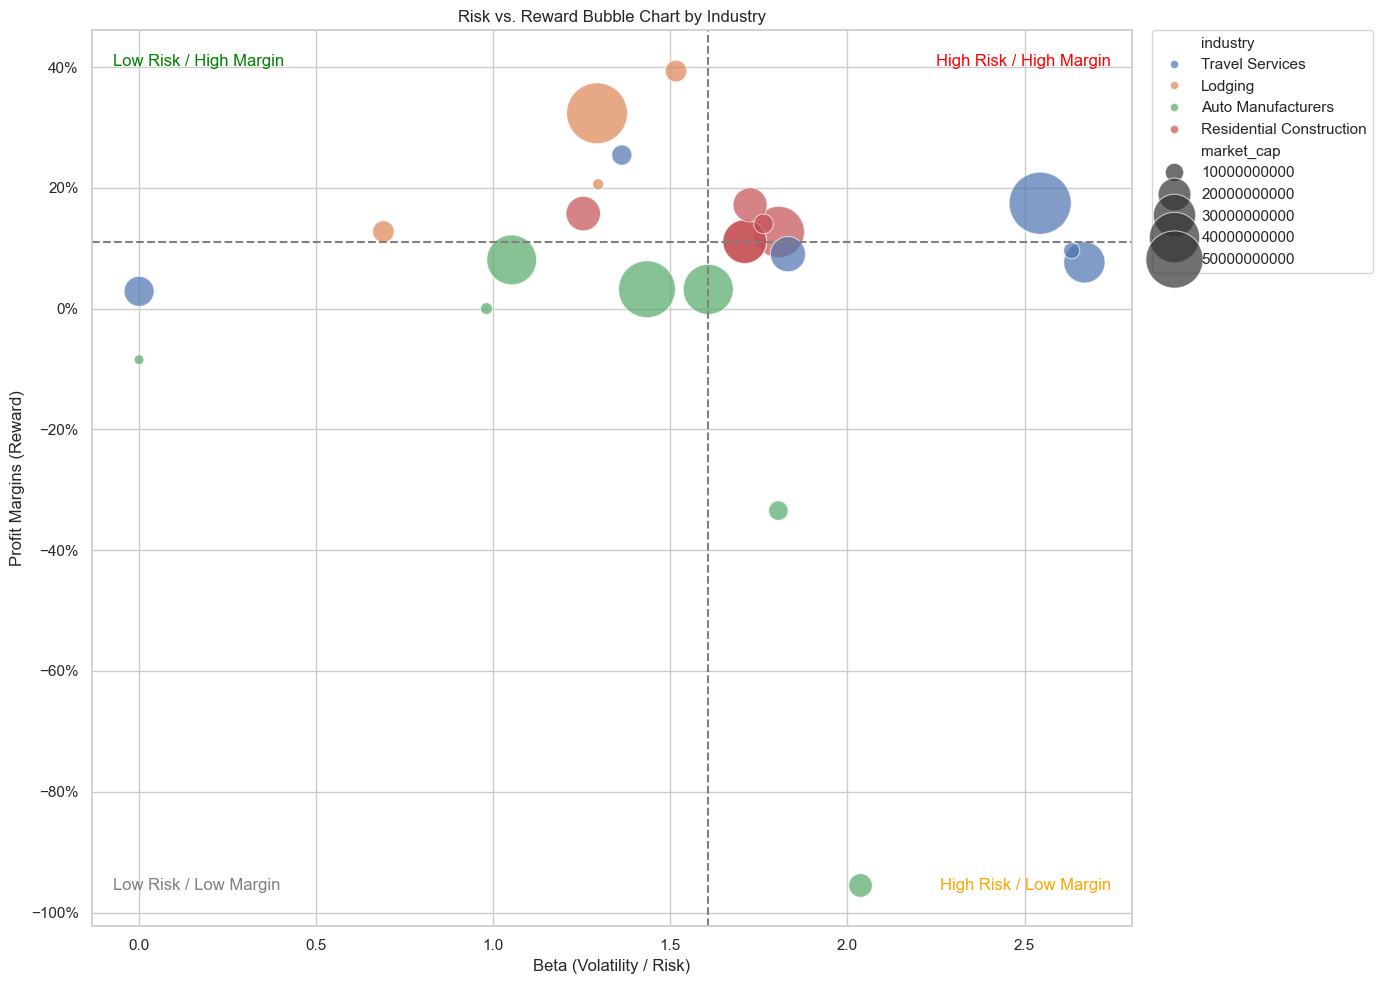

In [7]:
# ==============================================================================
# STEP 6: BUBBLE CHART
# ==============================================================================

# Justification for visual encodings:
# - X-axis (Beta): Represents market risk/volatility.
# - Y-axis (Profit Margins): Represents the reward/profitability.
# - Bubble Size (Market Cap): Shows the scale of each company.
# - Bubble Color (Industry): Helps identify industry clusters in the matrix.

fig, ax = plt.subplots(figsize=(14, 10))

# Calculate medians to create the crosshair (quadrants)
x_median = df_focus['beta'].median()
y_median = df_focus['profit_margins'].median()

# Create the bubble chart
sns.scatterplot(
    data=df_focus,
    x='beta',
    y='profit_margins',
    size='market_cap',
    sizes=(50, 2000),
    hue='industry',
    alpha=0.7,
    ax=ax
)

# Draw lines for the 4 quadrants
ax.axvline(x_median, color='grey', linestyle='--')
ax.axhline(y_median, color='grey', linestyle='--')

# Add Quadrant Labels directly using axes coordinates (0 to 1)
ax.text(0.98, 0.96, 'High Risk / High Margin', transform=ax.transAxes, ha='right', color='red')
ax.text(0.02, 0.96, 'Low Risk / High Margin', transform=ax.transAxes, ha='left', color='green')
ax.text(0.02, 0.04, 'Low Risk / Low Margin', transform=ax.transAxes, ha='left', color='grey')
ax.text(0.98, 0.04, 'High Risk / Low Margin', transform=ax.transAxes, ha='right', color='orange')

# 5. Formatting
ax.set_title("Risk vs. Reward Bubble Chart by Industry")
ax.set_xlabel("Beta (Volatility / Risk)")
ax.set_ylabel("Profit Margins (Reward)")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

# Move the legend outside the chart so it doesn't cover any bubbles
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

[*********************100%***********************]  4 of 4 completed


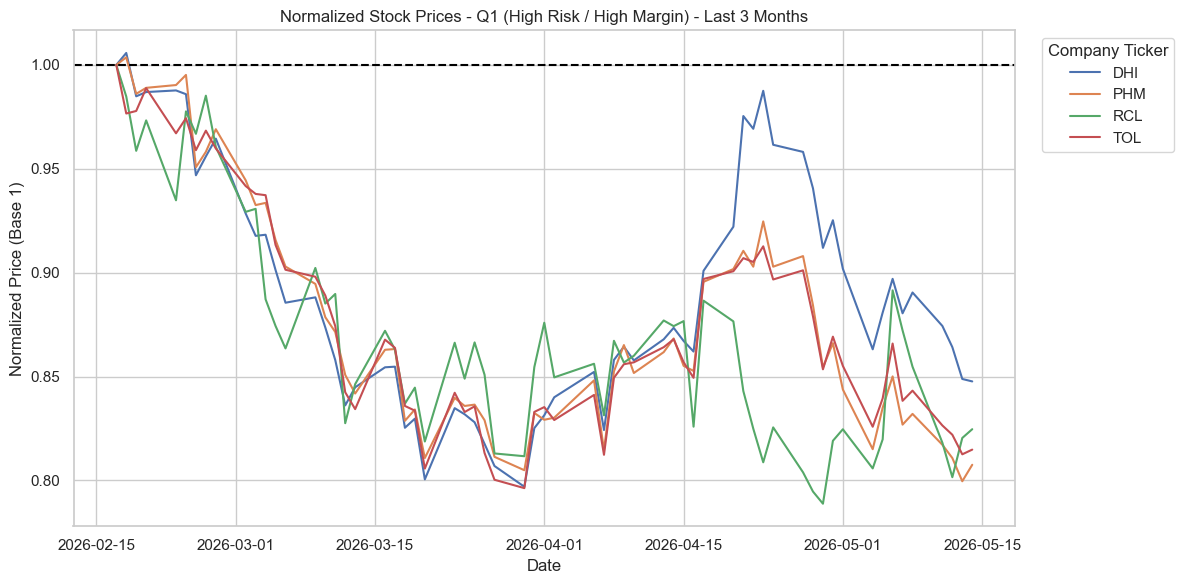

In [8]:
# ==============================================================================
# STEP 7: ZOOM INTO ONE QUADRANT
# ==============================================================================

# QUADRANT SELECTION JUSTIFICATION:
# I chose Quadrant 1 (High Risk / High Margin). It contains companies with 
# strong profits but high sensitivity to shocks (High Beta). In the context 
# of the Strait of Hormuz geopolitical tensions, we expect these high-beta 
# companies (especially in Travel and Auto) to show significant volatility 
# due to spikes in global oil prices and supply chain issues.

# Filter companies that are stricly in Quadrant 1 (Top Right)
q1_companies = df_focus[(df_focus['beta'] > x_median) & 
                        (df_focus['profit_margins'] > y_median)].copy()

if len(q1_companies) > 10:
    q1_companies = q1_companies.nlargest(10, 'market_cap')

# Extract the ticker symbols using the 'symbol' column
tickers = q1_companies['symbol'].tolist()
print(f"Downloading 3-month data for Q1 companies: {tickers}")

# Download the last 3 months of daily closing prices using yfinance
price_data = yf.download(tickers, period='3mo')['Close']

# Normalize all series to 1 on the first available trading day
normalized_data = price_data / price_data.iloc[0]

# Plotting the chart
fig, ax = plt.subplots(figsize=(12, 6))

for column in normalized_data.columns:
    ax.plot(normalized_data.index, normalized_data[column], label=column)

ax.set_title("Normalized Stock Prices - Q1 (High Risk / High Margin) - Last 3 Months")
ax.set_ylabel("Normalized Price (Base 1)")
ax.set_xlabel("Date")

ax.axhline(1.0, color='black', linestyle='--')

ax.legend(title="Company Ticker", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# GEOPOLITICAL OBSERVATIONS (Strait of Hormuz):
# 
# The impact of the geopolitical tensions in the Strait of Hormuz is clearly 
# visible on the chart for these Q1 companies (RCL, DHI, PHM, TOL). Since the 
# Strait is a critical oil chokepoint, the threat to global supplies directly 
# hit these high-beta stocks. For a cruise line like RCL, the spike in oil prices 
# means much higher operating costs, while for homebuilders, it fuels inflation 
# and fears of rising interest rates, which quickly kills consumer demand.
#
# Looking at the price action, these companies didn't just decline gradually; 
# they suffered a very sharp crash starting in late February, dropping nearly 
# 20% in just a few weeks. There was a small attempt at a recovery in mid-April, 
# especially for DHI, but it was short-lived. By May, the stocks had fallen 
# back down, showing that the market remains very worried and hasn't found 
# a stable bottom yet.
# ==============================================================================

[*********************100%***********************]  6 of 6 completed


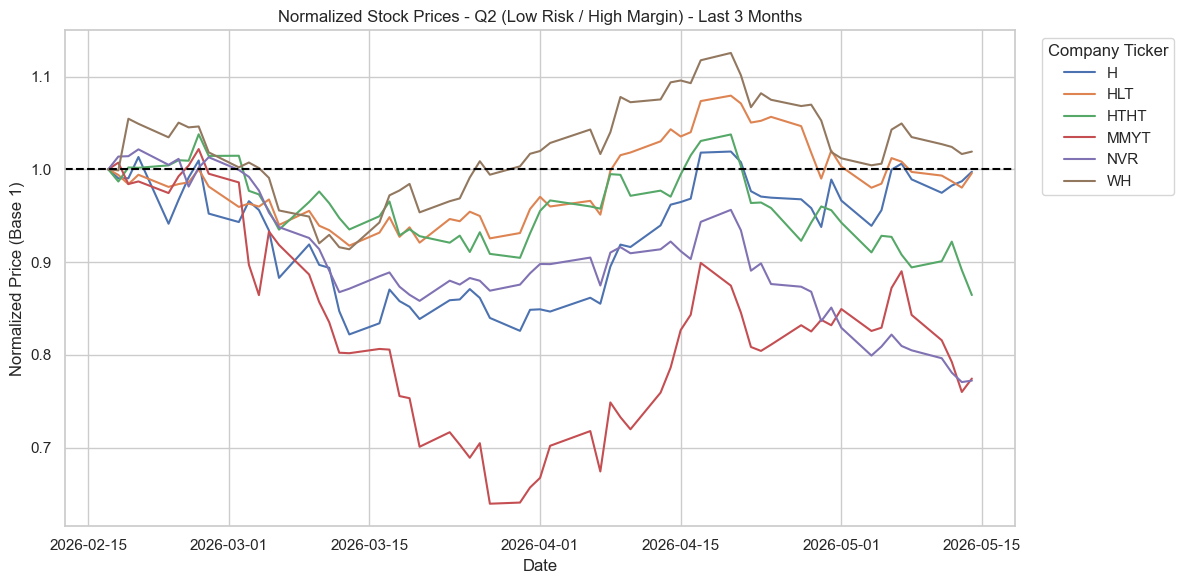

In [9]:
# ==============================================================================
# STEP 8: COMPARE WITH AN EXCLUDED QUADRANT
# ==============================================================================

# Justification:
# I chose Quadrant 2 (Low Risk / High Margin) to compare with Q1. 
# Since Q1 (High Beta) showed massive volatility during the Strait of Hormuz tensions, 
# it is interesting to see if Q2 (Low Beta) acted as a resilient "safe haven".

# Filter companies in Quadrant 2 (Top Left)
q2_companies = df_focus[(df_focus['beta'] <= x_median) & 
                        (df_focus['profit_margins'] > y_median)].copy()

if len(q2_companies) > 10:
    q2_companies = q2_companies.nlargest(10, 'market_cap')

tickers_q2 = q2_companies['symbol'].tolist()
print(f"Downloading 3-month data for Q2 companies: {tickers_q2}")

# Download data and normalize
price_data_q2 = yf.download(tickers_q2, period='3mo')['Close']
normalized_q2 = price_data_q2 / price_data_q2.iloc[0]

# Plotting the chart
fig, ax = plt.subplots(figsize=(12, 6))

for column in normalized_q2.columns:
    ax.plot(normalized_q2.index, normalized_q2[column], label=column)

ax.set_title("Normalized Stock Prices - Q2 (Low Risk / High Margin) - Last 3 Months")
ax.set_ylabel("Normalized Price (Base 1)")
ax.set_xlabel("Date")

ax.axhline(1.0, color='black', linestyle='--') 

ax.legend(title="Company Ticker", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# OBSERVATIONS & COMPARISON:
# 
# The difference in behavior between Q1 and Q2 is quite striking. While the 
# Q1 stocks (High Beta) dropped together like a "downward wall" with 15-20% losses, 
# this Q2 group is much more resilient. Most of these stocks, like HLT, H, or WH, 
# managed to stay close to the 1.0 baseline despite the geopolitical stress.
#
# This confirms that our quadrant logic works: the Low Beta of Q2 acted as a 
# stabilizer. Even with the tensions in the Strait of Hormuz causing market 
# panic, these companies were less sensitive to the shock than the high-risk 
# ones in Q1. Their high margins also likely helped them absorb rising costs. 
#
# We can see a lot more dispersion here than in Q1; for instance, WH actually 
# grew, while only MMYT (the red line) had a major drop. Overall, staying 
# within 5-10% of the starting price shows that this quadrant is a much 
# safer haven during a crisis.
# ==============================================================================

# Final Summary of Analysis: Consumer Cyclical Sector

### Sector Structure: Size, Profitability, and Risk
My analysis of the Consumer Cyclical sector revealed a very diverse environment. The sector is characterized by a few "mega-cap" companies that dominate the market, while the majority are smaller players. In terms of profitability, the sector shows a wide range of margins, with some industries like Lodging being extremely profitable, while others struggle with high operational costs. Regarding risk, the average Beta is relatively high (often above 1.2), which is typical for this sector as it depends heavily on consumer confidence and economic cycles.

### Industry Selection
I chose to focus on four specific industries to get a clear view of these contrasts:
* Auto Manufacturers: For their massive scale and revenue.
* Lodging: For their superior profit margins.
* Residential Construction: As a solid industry with high market caps.
* Travel Services: Because they represent high-risk, high-volatility profiles.

These four industries allowed me to compare very different business models within the same sector.

### Bubble Chart Insights
The Risk vs. Reward bubble chart was the most revealing part of the analysis. It showed that companies naturally cluster based on their industry. For example, Lodging companies tended to stay in the "Low Risk / High Margin" quadrant, acting as the "Sweet Spot" of the sector. On the other hand, Travel Services and some Auto companies were pushed toward the "High Risk" side. The chart proved that in this sector, being bigger (Market Cap) doesn't always mean being more profitable or less risky.

### Performance and Geopolitical Context
During the last 3 months, the tensions in the Strait of Hormuz had a visible impact on our companies:
1. High Risk Group (Q1): As expected, these companies (like RCL or DHI) were very exposed. They suffered sharp declines of 15-20%. The high oil prices and the fear of rising interest rates caused a "panic" effect, leading to a strong downward trend.
2. Low Risk Group (Q2): This group was much more resilient. While they didn't all grow, they stayed much closer to their initial price levels.

This difference in performance was exactly what I expected. The "Quadrant Logic" proved to be true: companies with a Low Beta acted as a shield against geopolitical shocks, while High Beta companies amplified the market's negative reaction. High profit margins also helped the resilient group to better absorb the economic pressure without their stock prices crashing.